# **ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ**

In [8]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import re
import gdown
from sklearn.preprocessing import StandardScaler

# Скачиваем базу данных hh_fixed.csv
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/hh_fixed.csv', None, quiet=True)

# Чтение файла
df = pd.read_csv('hh_fixed.csv', index_col=0)
print(f"Размер базы: {df.shape}")

Размер базы: (62967, 12)


# **ФУНКЦИИ ПРЕДОБРАБОТКИ (ПАРСИНГ)**

In [9]:


# Константы для перевода валют в рубли
currency_rate = {'usd': 65.0, 'eur': 70.0, 'грн': 2.7, 'бел': 30.0, ' kzt': 0.17,
                 'сум': 0.007, ' azn': 38.0, ' kgs': 0.9, ' amd': 0.13}

def extract_sex_age_years(arg):
    # Извлечение пола
    sex = 1.0 if 'муж' in str(arg).lower() else 0.0
    # Извлечение возраста (база 2019 года)
    try:
        years = 2019 - int(re.search(r'\d{4}', str(arg))[0])
    except:
        years = 0
    return sex, years

def extract_salary(arg):
    # Извлечение зарплаты и перевод в тысячи рублей
    try:
        value = float(re.search(r'\d+', str(arg).replace(' ', ''))[0])
        curr = str(arg).lower()
        for currency, rate in currency_rate.items():
            if currency in curr:
                value *= rate
                break
        return value / 1000.0
    except:
        return 0.0

# Простая функция для One-Hot Encoding без Keras utils
def to_ohe(value, num_classes):
    arr = np.zeros(num_classes)
    arr[int(value) if value < num_classes else num_classes-1] = 1.0
    return arr

# **ПОДГОТОВКА ВЫБОРКИ**

In [10]:


print("Обработка признаков...")

# Извлекаем пол и возраст
data_sex_age = df['Пол, возраст'].apply(extract_sex_age_years)
sex_features = np.array([x[0] for x in data_sex_age]).reshape(-1, 1)
age_features = np.array([x[1] for x in data_sex_age]).reshape(-1, 1)

# Нормируем возраст (StandardScaler)
scaler_age = StandardScaler()
age_features_scaled = scaler_age.fit_transform(age_features)

# Извлекаем целевую переменную (Зарплата)
y_train = df['ЗП'].apply(extract_salary).values.reshape(-1, 1).astype(np.float32)

# Для базовой модели Baseline соберем простые признаки: Пол и Возраст
# В оригинале x_train_01 мог включать больше данных, здесь сделаем основу
x_train_01 = np.hstack([sex_features, age_features_scaled]).astype(np.float32)

# Создание тензоров PyTorch
X_tensor = torch.from_numpy(x_train_01)
y_tensor = torch.from_numpy(y_train)

# Разделение на обучение и валидацию (80/20)
dataset = TensorDataset(X_tensor, y_tensor)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Загрузчики данных
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

Обработка признаков...


# **АРХИТЕКТУРА МОДЕЛИ НА PYTORCH**

In [11]:


# Эквивалент Sequential модели из задания
class SalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(SalaryModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Линейная активация на выходе для регрессии
        )

    def forward(self, x):
        return self.net(x)

model = SalaryModel(x_train_01.shape[1])
criterion = nn.MSELoss() # Среднеквадратичная ошибка
optimizer = optim.Adam(model.parameters(), lr=0.001) #
mae_metric = nn.L1Loss() # MAE

# **ЦИКЛ ОБУЧЕНИЯ**

In [12]:


epochs = 30
history = {'train_mae': [], 'val_mae': []}

print("Начало обучения...")
for epoch in range(epochs):
    model.train()
    train_mae_sum = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            mae = mae_metric(outputs, batch_y)
            train_mae_sum += mae.item()

    # Валидация
    model.eval()
    val_mae_sum = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_outputs = model(batch_X)
            mae = mae_metric(val_outputs, batch_y)
            val_mae_sum += mae.item()

    avg_train_mae = train_mae_sum / len(train_loader)
    avg_val_mae = val_mae_sum / len(val_loader)

    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(avg_val_mae)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1:2d}/{epochs} | MAE на обучении: {avg_train_mae:.2f} | MAE на валидации: {avg_val_mae:.2f}")

print(f"\nОбучение завершено. Финальная ошибка MAE: {history['val_mae'][-1]:.2f}")

Начало обучения...
Эпоха  1/30 | MAE на обучении: 45.59 | MAE на валидации: 41.02
Эпоха  5/30 | MAE на обучении: 42.71 | MAE на валидации: 40.79
Эпоха 10/30 | MAE на обучении: 42.61 | MAE на валидации: 41.16
Эпоха 15/30 | MAE на обучении: 42.64 | MAE на валидации: 40.66
Эпоха 20/30 | MAE на обучении: 42.62 | MAE на валидации: 40.46
Эпоха 25/30 | MAE на обучении: 42.66 | MAE на валидации: 40.20
Эпоха 30/30 | MAE на обучении: 42.65 | MAE на валидации: 40.42

Обучение завершено. Финальная ошибка MAE: 40.42


# **ВИЗУАЛИЗАЦИЯ**

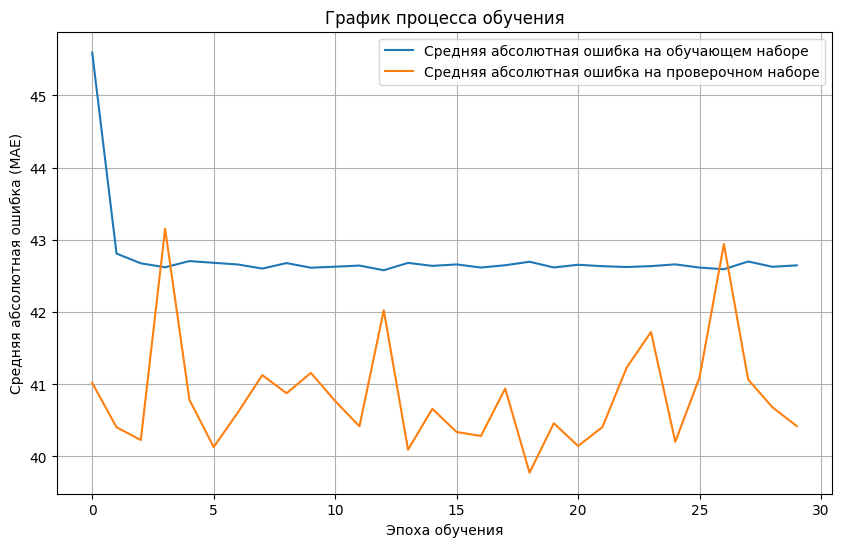

In [13]:


plt.figure(figsize=(10, 6))
plt.plot(history['train_mae'], label='Средняя абсолютная ошибка на обучающем наборе')
plt.plot(history['val_mae'], label='Средняя абсолютная ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Средняя абсолютная ошибка (MAE)')
plt.title('График процесса обучения')
plt.legend()
plt.grid(True)
plt.show()